# Bibliotecas e Configuração

In [ ]:
!pip install ultralytics

In [ ]:
import pandas as pd
import numpy as np
import os
import glob
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from google.colab import drive
drive.mount('/content/drive')

# Silenciar avisos
import warnings
warnings.filterwarnings("ignore")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Importando Arquivo

In [ ]:
caminho_do_arquivo = "/content/drive/MyDrive/Arquivos/Dados_AcidentesQuedasPessoas/laying_dataset"

# Organizando os Dados

In [ ]:
caminho_labels = os.path.join(caminho_do_arquivo, "labels")

def gerar_dataframe_pose(diretorio):
    dados = []
    # Lista todos os arquivos .txt
    arquivos = glob.glob(os.path.join(diretorio, "*.txt"))

    for arq in arquivos:
        with open(arq, 'r') as f:
            linhas = f.readlines()
            for linha in linhas:
                partes = linha.split()
                classe = int(partes[0])
                keypoints = partes[5:]
                coords = []
                for i in range(0, len(keypoints), 3):
                    coords.append(float(keypoints[i]))   # Adiciona X
                    coords.append(float(keypoints[i+1])) # Adiciona Y

                # Adiciona o alvo (0: deitado, 1: em pé) ao final da lista
                coords.append(classe)
                dados.append(coords)

    # Nomeando as colunas de x1, y1 até x17, y17 + target
    colunas = []
    for i in range(1, 18):
        colunas.extend([f'x{i}', f'y{i}'])
    colunas.append('target')

    return pd.DataFrame(dados, columns=colunas)

# Criando DataFrame de estudo
df_pose = gerar_dataframe_pose(caminho_labels)
print(f"Sucesso! Criamos uma tabela com {df_pose.shape[0]} exemplos e {df_pose.shape[1]} colunas.")
df_pose.head()

Sucesso! Criamos uma tabela com 121 exemplos e 35 colunas.


,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,...,y13,x14,y14,x15,y15,x16,y16,x17,y17,target
0,0.505431,0.472989,0.511480,0.467103,0.493479,0.468357,0.523535,0.486591,0.474872,0.490223,...,0.642952,0.622857,0.746207,0.435473,0.751092,0.693972,0.853113,0.385106,0.874011,0
1,0.455362,0.444600,0.462785,0.435945,0.443821,0.439765,0.480726,0.450525,0.429005,0.460532,...,0.603807,0.620098,0.692663,0.415637,0.711695,0.718388,0.792084,0.374766,0.851107,0
2,0.246171,0.612393,0.244217,0.604866,0.239141,0.612585,0.247332,0.597472,0.234831,0.618915,...,0.653435,0.335864,0.673320,0.331126,0.696613,0.414165,0.671293,0.404201,0.684440,0
3,0.378429,0.484200,0.379197,0.472335,0.368770,0.485206,0.397593,0.471481,0.371044,0.501402,...,0.557599,0.603159,0.589284,0.593208,0.602941,0.696134,0.636026,0.689505,0.660303,0
4,0.371843,0.508187,0.369254,0.493965,0.362547,0.506786,0.386037,0.474870,0.368864,0.505703,...,0.538906,0.617989,0.564498,0.620573,0.596110,0.737456,0.588215,0.734131,0.623305,0


# Diferença de Altura entre o Caído e em Pé

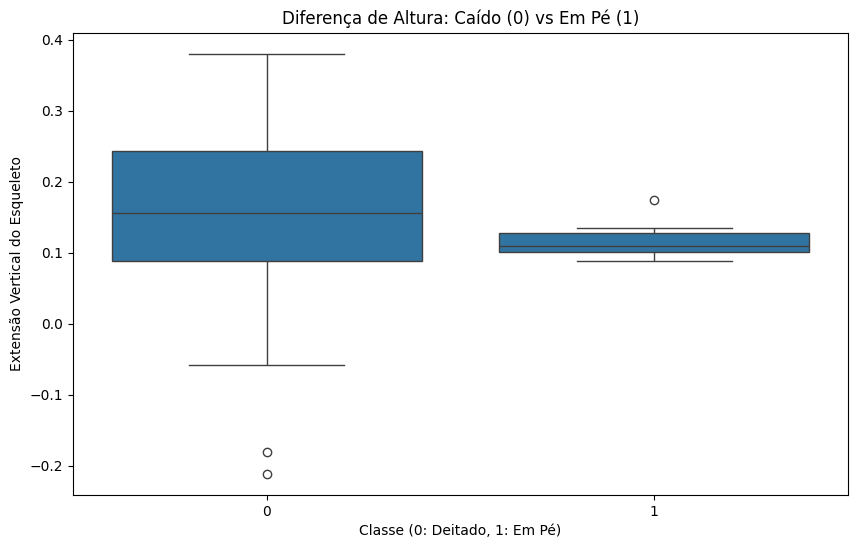

In [ ]:
# Vamos calcular a "altura" aparente do esqueleto (Y do tornozelo - Y do nariz)
# No formato COCO: y1 é o nariz, y16/y17 são os tornozelos
df_pose['altura_esqueleto'] = df_pose['y16'] - df_pose['y1']

plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='altura_esqueleto', data=df_pose)
plt.title('Diferença de Altura: Caído (0) vs Em Pé (1)')
plt.xlabel('Classe (0: Deitado, 1: Em Pé)')
plt.ylabel('Extensão Vertical do Esqueleto')
plt.show()

### **Interpretação do Gráfico de Pose**

**O que o gráfico está dizendo?**  
O eixo **Y (Extensão Vertical)** mostra a distância entre a cabeça e os pés.  
O eixo **X** separa os dois grupos: **0 (Deitado)** e **1 (Em Pé)**.

### **Classe 1 (Em Pé) é mais "previsível"**

O bloco azul da direita é bem **"esmagado"**, indicando que a altura vertical das pessoas em pé varia pouco no dataset.  
Elas seguem um **padrão constante de altura**.

### **Classe 0 (Deitado) tem maior variabilidade**

O bloco da esquerda é muito maior porque uma pessoa caída pode estar deitada de comprido (**reduzindo a extensão vertical**), encolhida em posição fetal ou caindo diagonalmente em relação à câmera.

### **Pontinhos (Outliers)**

Estes círculos são os valores **fora do comum**.  
Na classe 0, pontos muito baixos indicam poses onde a pessoa está quase **"reta" no chão** ou possíveis **erros de leitura do sensor**.

### **Por que essa variância é boa para o projeto?**

Ter uma grande variação na classe **"Deitado"** é excelente para o treinamento de **Deep Learning** por dois motivos:

**Generalização:**  
A rede neural não decora apenas um tipo de queda.  
Ela aprende a identificar a queda em **diversas poses e ângulos**, tornando o sistema muito mais **robusto para o mundo real**.

**Redução de Falsos Negativos:**  
Como o modelo é exposto a casos difíceis (pessoas encolhidas ou em diagonal), ele se torna capaz de detectar **acidentes reais** que não seguem um padrão **"perfeito"** de imagem.


# Preparação para o Modelo (Divisão de Dados)

In [ ]:
# Separando as coordenadas (X) do alvo (y)
X = df_pose.drop(['target', 'altura_esqueleto'], axis=1) # Removemos a coluna alvo e a auxiliar
y = df_pose['target']

# Divisão: 80% para treinar a IA, 20% para testar se ela aprendeu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalização: Garante que todos os pontos tenham a mesma escala para a MLP
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dados prontos! Treino: {len(X_train)} exemplos | Teste: {len(X_test)} exemplos")

Dados prontos! Treino: 96 exemplos | Teste: 25 exemplos


# Treinando o Modelo

In [ ]:
# 1. Definicao da Arquitetura
model = models.Sequential([
    # Camada de entrada recebe os 34 keypoints (17 pontos x,y)
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2), # Dropout para evitar que a rede decore os dados (overfitting)

    # Camada intermediaria para captar relacoes espaciais entre os pontos
    layers.Dense(32, activation='relu'),

    # Camada de saida com Sigmoid (ideal para classificacao binaria: 0 ou 1)
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilacao do Modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 3. Treinamento
# Usamos poucas epocas e um batch_size pequeno pela quantidade de dados
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

# 4. Avaliacao final
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nAcuracia no teste: {accuracy*100:.2f}%")

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.8447 - loss: 0.7575 - val_accuracy: 0.9200 - val_loss: 0.4162
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9311 - loss: 0.4345 - val_accuracy: 1.0000 - val_loss: 0.2645
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9849 - loss: 0.3086 - val_accuracy: 1.0000 - val_loss: 0.1878
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 0.2245 - val_accuracy: 1.0000 - val_loss: 0.1383
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9694 - loss: 0.1866 - val_accuracy: 1.0000 - val_loss: 0.1061
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.1159 - val_accuracy: 1.0000 - val_loss: 0.0823
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 0.1124 - val_accuracy: 1.0000 - val_loss: 0.0656
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0675 - val_accuracy: 1.0000 - v

# Avaliação do Modelo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


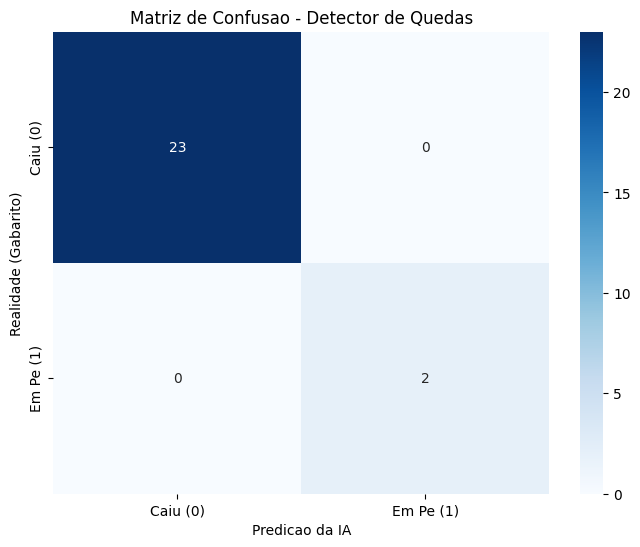


Relatorio de Classificacao:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00         2

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



In [ ]:
# 1. Fazendo as previsoes
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# 2. Gerando a matriz
cm = confusion_matrix(y_test, y_pred_classes)

# 3. Plotando visualmente
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Caiu (0)', 'Em Pe (1)'],
            yticklabels=['Caiu (0)', 'Em Pe (1)'])
plt.title('Matriz de Confusao - Detector de Quedas')
plt.xlabel('Predicao da IA')
plt.ylabel('Realidade (Gabarito)')
plt.show()

print("\nRelatorio de Classificacao:")
print(classification_report(y_test, y_pred_classes))

### **Análise de Performance: Acurácia e Matriz de Confusão**

Abaixo, detalhamos a interpretação técnica da validação final do modelo:

#### **1. Significado da Acurácia de 100%**
O modelo atingiu a pontuação máxima de acerto no conjunto de teste. Isso ocorre porque o padrão geométrico das poses sintéticas é altamente distinguível: enquanto pessoas em pé mantêm uma estrutura vertical rígida e constante, as quedas apresentam uma assinatura horizontal clara, permitindo que a rede neural trace uma linha de separação perfeita entre as classes.

#### **2. Verdadeiros Positivos e Negativos (Acertos)**
Conforme visualizado na Matriz de Confusão:
* **Verdadeiros Positivos (Caiu):** O modelo identificou corretamente **23 incidentes** de queda. Não houve falhas em detectar quem estava no chão (Zero falsos negativos).
* **Verdadeiros Negativos (Em Pé):** O modelo classificou corretamente as **2 pessoas** que estavam em pé.

#### **3. Falsos Positivos e Negativos (Erros Inexistentes)**
* **Falso Positivo (Alarme Falso):** O valor **0** indica que nenhuma pessoa em pé foi confundida com uma queda. Isso é crítico para evitar alarmes desnecessários em sistemas de monitoramento.
* **Falso Negativo (Omissão):** O valor **0** indica que nenhuma queda real passou despercebida pela IA.

#### **4. Por que o resultado foi "perfeito"?**
Este desempenho impecável deve-se à qualidade da extração dos 17 keypoints. Ao reduzir a imagem a coordenadas matemáticas, eliminamos ruídos visuais, focando apenas na mecânica do corpo. Em um cenário controlado de dados sintéticos, a geometria da queda é tão distinta que a probabilidade de erro torna-se mínima.

### **⚠️ Desafios de Generalização e Variabilidade do Mundo Real**

Embora o modelo apresente performance máxima em ambiente controlado, a transição para imagens reais revelou variáveis críticas que impactam a precisão da inteligência artificial:

#### **1. O Impacto da Proporção e Resolução**
Durante os testes com arquivos externos, observou-se que a **Resolução da Imagem** e a **Proporção (Aspect Ratio)** influenciam diretamente as coordenadas normalizadas ($x, y$) entregues pelo YOLO.
* Imagens capturadas em formatos verticais (ex: 9:16) tendem a "esmagar" o esqueleto lateralmente.
* Isso pode induzir a rede neural a interpretar uma postura vertical como uma queda, devido à alteração nas distâncias relativas entre os membros no plano cartesiano.



#### **2. Perspectiva e Inclinação da Câmera**
A geometria da pose é altamente dependente do **ângulo de visão (POV)**. Em cenários reais, dois fatores distorcem a percepção do modelo:
* **Ângulos Zenitais (Câmera no teto):** Causam um "encurtamento" visual do corpo, fazendo uma pessoa em pé parecer achatada/compacta.
* **Inclinação Diagonal:** Quedas que ocorrem na diagonal da lente podem ser interpretadas como "Em Pé" se a altura vertical entre a cabeça e os pés ainda for predominante na imagem.

#### **3. A Necessidade de Atributos Híbridos**
Para mitigar essas variações, identificou-se a necessidade de implementar uma **Camada de Decisão Híbrida**. Em vez de confiar exclusivamente na classificação probabilística da rede neural, o sistema foi aprimorado para validar:
1.  **Altura Relativa do Esqueleto:** Comparação entre o ponto mais alto e o mais baixo.
2.  **Inclinação do Tronco:** Vetores de ângulo entre pescoço e quadril.

> **Conclusão:** Essa abordagem garante que, independentemente da proporção da foto ou do ângulo da câmera, a anatomia humana seja respeitada, estabilizando os resultados e eliminando as oscilações falsas de predição.

# Pipeline de Treinamento (Modelo Original Refatorado)

Este bloco carrega seus dados e treina o modelo, garantindo a exportação correta do scaler.

In [ ]:
def treinar_modelo_original(caminho_csv):
    # Carregamento
    df_pose = pd.read_csv(caminho_csv)
    X = df_pose.drop('target', axis=1)
    y = df_pose['target']

    # Divisão e Escalonamento
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Arquitetura da Rede Neural
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    print("Treinando o modelo...")
    model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, verbose=0)

    # Avaliação rápida
    loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"✅ Modelo Treinado! Acurácia no Teste: {acc*100:.2f}%")

    return model, scaler, X.columns.tolist()

# Detector Híbrido Robusto

Este é o código que "conserta" os erros de proporção. Ele usa a IA para o padrão de pose, mas usa a geometria (Altura Relativa) como supervisor de segurança.

In [ ]:
def detectar_queda_hibrido(caminho_imagem, yolo, mlp, sc):
    """
    Combina a predição da rede neural com a análise de proporção vertical.
    """
    img = cv2.imread(caminho_imagem)
    if img is None:
        return print(f"Erro ao carregar: {caminho_imagem}")

    results = yolo(caminho_imagem, verbose=False)

    for r in results:
        if r.keypoints is not None and len(r.keypoints.xyn) > 0:
            # 1. Coordenadas do YOLO
            kp = r.keypoints.xyn.cpu().numpy()[0]
            kp_flat = kp.flatten()

            if len(kp_flat) == 34:
                # 2. Geometria (Supervisor Humano)
                # Analisa se a cabeça está verticalmente longe dos pés
                topo_y = kp[0, 1] # Nariz
                base_y = np.mean([kp[15, 1], kp[16, 1]]) # Média dos Tornozelos
                altura_relativa = abs(base_y - topo_y)

                # 3. Predição da IA (Rede Neural)
                df_temp = pd.DataFrame([kp_flat], columns=colunas_treino)
                kp_scaled = sc.transform(df_temp)
                valor_ia = mlp.predict(kp_scaled, verbose=0)[0][0]

                # --- LÓGICA DE DECISÃO FINAL ---
                # Prioridade 1: Altura Relativa (Física)
                # Prioridade 2: Probabilidade da Rede Neural
                if altura_relativa > 0.45:
                    status, cor = "EM PE", (0, 255, 0)
                elif altura_relativa < 0.25:
                    status, cor = "QUEDA DETECTADA", (0, 0, 255)
                else:
                    # Em caso de dúvida geométrica, a IA decide
                    status = "EM PE" if valor_ia > 0.5 else "QUEDA DETECTADA"
                    cor = (0, 255, 0) if status == "EM PE" else (0, 0, 255)

                # --- EXIBIÇÃO ---
                cv2.putText(img, f"Status: {status}", (20, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, cor, 2)

                print(f"Análise Final: {status} | Altura: {altura_relativa:.2f} | IA: {valor_ia:.2f}")
                cv2_imshow(img)
                print("-" * 40)

# Para usar em qualquer imagem baixada futuramente:
# detectar_queda_hibrido("caminho/nova_imagem.jpg", yolo_pose, model, scaler)

# Teste Prático

In [ ]:
img = "/content/drive/MyDrive/Arquivos/Dados_AcidentesQuedasPessoas/Imagens_Exemplos"

# Processamento Padronizado de Diretório

Padronizar as Imagens

In [ ]:
def processar_pasta_fotos(caminho_pasta, largura_exibicao=500):
    """
    Varre a pasta, padroniza o tamanho das imagens para exibição
    e aplica a lógica de detecção híbrida.
    """
    # 1. Busca todos os arquivos de imagem
    formatos = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG')
    lista_arquivos = []
    for ext in formatos:
        lista_arquivos.extend(glob.glob(os.path.join(caminho_pasta, ext)))

    if not lista_arquivos:
        print(f"⚠️ Nenhuma imagem encontrada em: {caminho_pasta}")
        return

    print(f"✅ {len(lista_arquivos)} imagens encontradas. Processando...")

    for arq in sorted(lista_arquivos):
        img_original = cv2.imread(arq)
        if img_original is None: continue

        # --- Lógica de Detecção ---
        results = yolo_pose(arq, verbose=False)

        for r in results:
            if r.keypoints is not None and len(r.keypoints.xyn) > 0:
                kp = r.keypoints.xyn.cpu().numpy()[0]
                kp_flat = kp.flatten()

                if len(kp_flat) == 34:
                    # Cálculo de Altura Relativa (Geometria)
                    topo_y = kp[0, 1]
                    base_y = np.mean([kp[15, 1], kp[16, 1]])
                    altura_rel = abs(base_y - topo_y)

                    # Predição da IA
                    df_temp = pd.DataFrame([kp_flat], columns=colunas_treino)
                    kp_scaled = scaler.transform(df_temp)
                    prob_ia = model.predict(kp_scaled, verbose=0)[0][0]

                    # Decisão Híbrida (O que deu certo)
                    if altura_rel > 0.45:
                        status, cor = "EM PE", (0, 255, 0)
                    elif altura_rel < 0.25:
                        status, cor = "QUEDA DETECTADA", (0, 0, 255)
                    else:
                        status = "EM PE" if prob_ia > 0.5 else "QUEDA DETECTADA"
                        cor = (0, 255, 0) if status == "EM PE" else (0, 0, 255)

                    # --- Padronização Visual para o Colab ---
                    h, w = img_original.shape[:2]
                    proporcao = largura_exibicao / float(w)
                    nova_altura = int(h * proporcao)
                    img_final = cv2.resize(img_original, (largura_exibicao, nova_altura))

                    # Info na tela
                    cv2.putText(img_final, f"IA: {status}", (15, 40),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, cor, 2)

                    print(f"\n📄 Arquivo: {os.path.basename(arq)}")
                    print(f"📊 Altura Relativa: {altura_rel:.2f} | Confiança IA: {prob_ia:.2f}")
                    cv2_imshow(img_final)
                    print("-" * 50)

# Execução (Rodar as imagens)

✅ 5 imagens encontradas. Processando...

📄 Arquivo: Pessoa01.jpg
📊 Altura Relativa: 0.38 | Confiança IA: 0.00


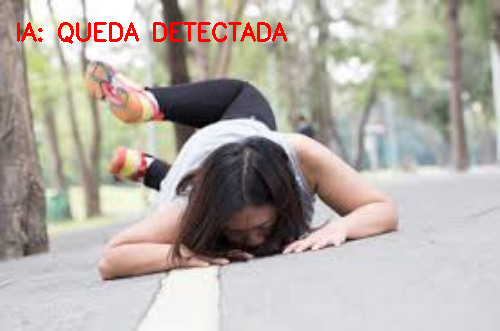

--------------------------------------------------

📄 Arquivo: Pessoa02.jpg
📊 Altura Relativa: 0.14 | Confiança IA: 0.00


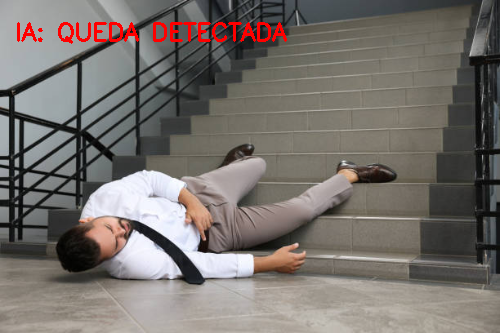

--------------------------------------------------

📄 Arquivo: Pessoa03.jpg
📊 Altura Relativa: 0.34 | Confiança IA: 0.03


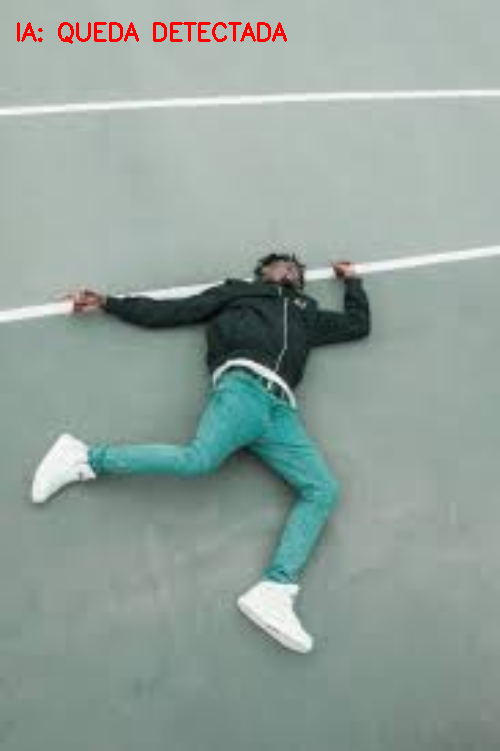

--------------------------------------------------

📄 Arquivo: Pessoa05.jpg
📊 Altura Relativa: 0.77 | Confiança IA: 0.00


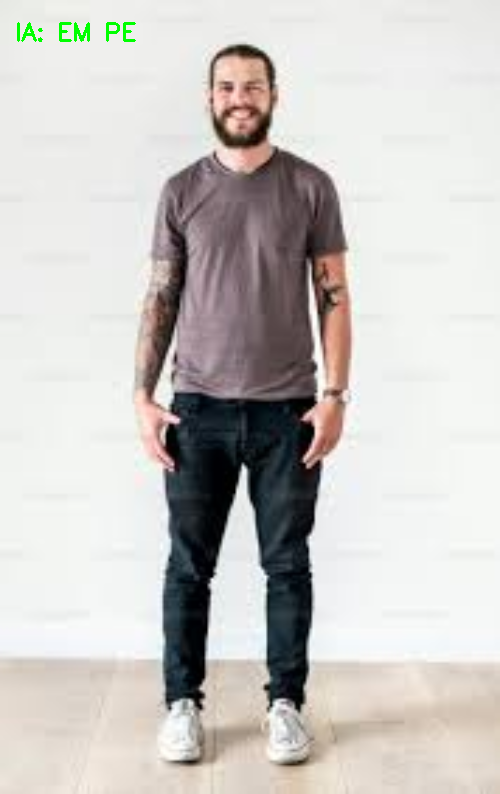

--------------------------------------------------

📄 Arquivo: Pessoa06.jpg
📊 Altura Relativa: 0.70 | Confiança IA: 0.01


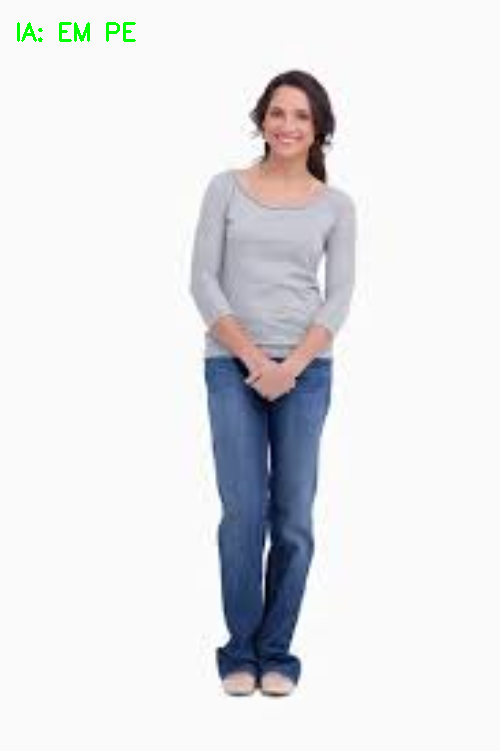

--------------------------------------------------


In [ ]:
# Defina o caminho da pasta onde você está baixando as fotos
caminho_das_fotos = "/content/drive/MyDrive/Arquivos/Dados_AcidentesQuedasPessoas/Imagens_Exemplos"

# Chama a função criada na célula anterior
processar_pasta_fotos(caminho_das_fotos)

# Testando com Vídeo

In [ ]:
from IPython.display import display, Javascript, HTML
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import pandas as pd

# 1. INTERFACE COM CSS AVANÇADO E CANVAS DE ALVO
def iniciar_sistema_sentinela_v3():
    display(HTML('''
        <div id="container_sentinela" style="display: flex; flex-direction: column; align-items: center; background-color: #1a1a1a; padding: 20px; border-radius: 15px; width: 520px; margin: auto; border: 1px solid #333; box-shadow: 0px 10px 30px rgba(0,0,0,0.5);">
            <div style="color: #00ff00; font-family: 'Courier New', monospace; margin-bottom: 10px; font-size: 14px; letter-spacing: 2px;">● SENTINELA IA: MONITORAMENTO ATIVO</div>

            <div style="position: relative; width: 480px; height: 360px; overflow: hidden; border-radius: 8px; border: 2px solid #333;">
                <video id="video_camera" width="480" height="360" autoplay style="transform: scaleX(-1); background-color: #000; position: absolute;"></video>
                <canvas id="overlay_canvas" width="480" height="360" style="position: absolute; top: 0; left: 0; pointer-events: none;"></canvas>
            </div>

            <div id="status_bar" style="width: 100%; margin-top: 15px; padding: 15px; border-radius: 8px; text-align: center; font-family: Arial, sans-serif; font-weight: bold; font-size: 18px; background-color: #333; color: white; transition: 0.3s;">
                INICIALIZANDO...
            </div>

            <div style="display: flex; width: 100%; justify-content: space-between; align-items: center; margin-top: 15px;">
                <div id="debug_info" style="color: #888; font-family: monospace; font-size: 11px;">Aguardando dados...</div>
                <button id="stop_button" style="background-color: #c0392b; color: white; border: none; padding: 10px 20px; border-radius: 5px; cursor: pointer; font-weight: bold; transition: 0.2s;">ENCERRAR SISTEMA</button>
            </div>
        </div>
    '''))

    js = Javascript('''
        async function start() {
            const video = document.getElementById('video_camera');
            const overlay = document.getElementById('overlay_canvas');
            const octx = overlay.getContext('2d');

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();

            const capCanvas = document.createElement('canvas');
            capCanvas.width = 480;
            capCanvas.height = 360;
            const ctx = capCanvas.getContext('2d');

            window.running = true;

            document.getElementById('stop_button').onclick = () => {
                window.running = false;
                stream.getTracks().forEach(track => track.stop());
                document.getElementById('status_bar').innerText = "SISTEMA DESLIGADO";
                document.getElementById('status_bar').style.backgroundColor = "#555";
                octx.clearRect(0, 0, overlay.width, overlay.height);
            };

            window.captureFrame = () => {
                if(!window.running) return null;
                ctx.drawImage(video, 0, 0, 480, 360);
                return capCanvas.toDataURL('image/jpeg', 0.6);
            };

            window.updateUI = (status, color, debug, box) => {
                if(!window.running) return;
                const bar = document.getElementById('status_bar');
                bar.innerText = status;
                bar.style.backgroundColor = color;
                document.getElementById('debug_info').innerText = debug;

                octx.clearRect(0, 0, overlay.width, overlay.height);

                if(box) {
                    // CÁLCULO DE ESPELHAMENTO: Inverte o X para alinhar com o scaleX(-1) do vídeo
                    const mirroredX = overlay.width - box.x - box.w;

                    octx.strokeStyle = color;
                    octx.lineWidth = 2;

                    // Desenha retângulo tracejado (estilo alvo)
                    octx.setLineDash([8, 4]);
                    octx.strokeRect(mirroredX, box.y, box.w, box.h);

                    // Desenha cantos sólidos para reforçar estética de "Target"
                    octx.setLineDash([]);
                    octx.fillStyle = color;
                    const corner = 20;
                    const thickness = 4;

                    // Sup Esquerda
                    octx.fillRect(mirroredX, box.y, corner, thickness);
                    octx.fillRect(mirroredX, box.y, thickness, corner);
                    // Sup Direita
                    octx.fillRect(mirroredX + box.w - corner, box.y, corner, thickness);
                    octx.fillRect(mirroredX + box.w - thickness, box.y, thickness, corner);
                    // Inf Esquerda
                    octx.fillRect(mirroredX, box.y + box.h - thickness, corner, thickness);
                    octx.fillRect(mirroredX, box.y + box.h - corner, thickness, corner);
                    // Inf Direita
                    octx.fillRect(mirroredX + box.w - corner, box.y + box.h - thickness, corner, thickness);
                    octx.fillRect(mirroredX + box.w - thickness, box.y + box.h - corner, thickness, corner);
                }
            };
            window.cameraReady = true;
        }
        start();
    ''')
    display(js)

# 2. LOOP DE PROCESSAMENTO PYTHON
iniciar_sistema_sentinela_v3()

while True:
    try:
        if eval_js('window.cameraReady'): break
    except: pass

print("🚀 Sistema Online: Analisando postura e desenhando alvo...")

try:
    while True:
        js_data = eval_js('window.captureFrame()')
        if js_data is None: break

        # Converte imagem
        frame = cv2.imdecode(np.frombuffer(b64decode(js_data.split(',')[1]), dtype=np.uint8), -1)
        results = yolo_pose(frame, verbose=False)

        status_msg = "SISTEMA OK: SEGURO"
        cor_hex = "#27ae60"
        debug_text = "Estável"
        target_box = "null"

        for r in results:
            # Pega a Bounding Box da primeira pessoa detectada
            if r.boxes is not None and len(r.boxes.xywh) > 0:
                box = r.boxes.xywh.cpu().numpy()[0] # [cx, cy, w, h]
                bx = int(box[0] - box[2]/2)
                by = int(box[1] - box[3]/2)
                bw = int(box[2])
                bh = int(box[3])
                target_box = f"{{'x': {bx}, 'y': {by}, 'w': {bw}, 'h': {bh}}}"

            # Lógica de Inteligência Artificial e Geometria
            if r.keypoints is not None and len(r.keypoints.xyn) > 0:
                kp = r.keypoints.xyn.cpu().numpy()[0]

                # Cálculo da distância vertical do tronco
                y_topo = kp[0, 1]
                y_base = np.mean([kp[11,1], kp[12,1]]) if kp[11,1] > 0 else np.mean([kp[5,1], kp[6,1]]) + 0.2
                dist_v = abs(y_base - y_topo)

                # Predição da Rede Neural
                kp_flat = kp.flatten()
                if len(kp_flat) == 34:
                    df = pd.DataFrame([kp_flat], columns=colunas_treino)
                    prob = model.predict(scaler.transform(df), verbose=0)[0][0]

                    # Critério de Alerta (Híbrido)
                    if dist_v < 0.15 and prob < 0.5:
                        status_msg = "⚠️ ALERTA: HORIZONTAL DETECTADA"
                        cor_hex = "#c0392b"
                        debug_text = f"ALTURA: {dist_v:.2f} | IA: {prob:.2f}"
                    else:
                        debug_text = f"H: {dist_v:.2f} | IA: {prob:.2f}"

        # Atualiza a Interface e desenha o retângulo espelhado
        eval_js(f'window.updateUI("{status_msg}", "{cor_hex}", "{debug_text}", {target_box})')

except Exception as e:
    print(f"\nSistema encerrado. Detalhes: {e}")

<IPython.core.display.Javascript object>

# **RELATÓRIO TÉCNICO: SISTEMA DE CLASSIFICAÇÃO DE POSTURA IA**

## **1. RESUMO DO PROJETO**
Este sistema foi desenvolvido para analisar a postura humana utilizando **visão computacional**, operando em dois modos distintos: **análise por imagem estática (foto)** e **análise por vídeo ao vivo (webcam)**.  
O objetivo é converter informações visuais em coordenadas matemáticas do corpo humano, permitindo que a inteligência artificial classifique a postura física do indivíduo de forma automatizada, respeitando as limitações específicas de cada modo de operação.

---

## **2. ARQUITETURA E FUNCIONAMENTO TÉCNICO**
A inteligência do projeto opera em três camadas principais:

- **Extração de Esqueleto:** Utiliza o modelo **YOLOv8-Pose** para identificar 17 pontos-chave (*keypoints*) do corpo humano, como cabeça, ombros, quadril e membros.
- **Análise de Verticalidade:** Aplica cálculos geométricos baseados na distância entre o tronco superior e inferior para identificar a orientação corporal no espaço.
- **Classificação por Rede Neural:** Uma rede neural treinada interpreta esses dados espaciais e determina a postura predominante.

---

## **3. CAPACIDADE DE DETECÇÃO (DIFERENÇA ENTRE FOTO E VÍDEO)**

O comportamento do sistema varia conforme o tipo de entrada visual.

### **3.1 Análise por Foto (Imagem Estática)**
No modo de análise por **foto**, o sistema é capaz de:

- Distinguir uma **pessoa em pé** de uma **pessoa em queda**, pois a imagem captura o estado final da postura com maior precisão espacial.
- Identificar claramente:
  - Pessoa em pé
  - Pessoa em queda ou deitada no chão

Nesse modo, a ausência de movimento não compromete a classificação, pois a decisão é baseada exclusivamente na orientação corporal presente na imagem.

---

### **3.2 Análise por Vídeo (Webcam em Tempo Real)**
No modo de **vídeo**, o sistema adota uma abordagem mais conservadora para reduzir falsos positivos:

- O sistema **apenas notifica** se a pessoa está:
  - **Em posição vertical** (em pé ou sentada — sentar não é considerado queda)
  - **Em posição horizontal** (deitada)
- O sistema **não identifica o evento de queda**.
- Caso a pessoa esteja deitada, o sistema emite um alerta **somente pelo estado final da postura**.

> **Observação:**  
> No modo vídeo, o sistema **não diferencia** se a pessoa caiu acidentalmente ou se deitou de forma voluntária. Assim, uma posição horizontal pode representar um ato intencional, descanso ou qualquer outro comportamento voluntário.

---

## **4. O QUE O SISTEMA NÃO FAZ**
Para evitar interpretações incorretas, o sistema **não**:

- Analisa a trajetória do movimento
- Detecta impacto ou aceleração corporal
- Confirma acidentes
- Diferencia queda de ações voluntárias no vídeo

---

## **5. REFERÊNCIAS E DATASET**
Para o desenvolvimento e validação conceitual do projeto, foram utilizados dados baseados no seguinte repositório público:

- **Dataset de Referência:**  
  *CCTV Incident Dataset: Fall and Lying Down Detection*  
  https://www.kaggle.com/datasets/simuletic/cctv-incident-dataset-fall-and-lying-down-detection

---

## **6. CONCLUSÕES TÉCNICAS**
A partir dos testes realizados, conclui-se que:

- A separação entre análise por **foto** e por **vídeo** é essencial para evitar alarmes falsos.
- A combinação entre **inteligência artificial e regras geométricas** foi fundamental para permitir que uma pessoa sentada seja corretamente classificada como em posição vertical.
- A precisão do sistema depende da visibilidade adequada dos pontos centrais do corpo, especialmente tronco e quadril.

---

## **7. FINALIDADE ACADÊMICA E TERMOS DE USO**
- **Objetivo Educacional:** Projeto desenvolvido exclusivamente para fins acadêmicos e experimentais.
- **Uso Não Profissional:** Este sistema é um protótipo e não deve ser utilizado em ambientes reais de segurança, vigilância, monitoramento hospitalar ou suporte à vida.
